In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset_builder import DatasetBuilder
from src.features.feature_extractor import FeatureExtractor
from src.data.dataset import KidneyStoneDataset
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor

from src.pipelines.xgboost_pipeline import XGBoostExperiment



In [3]:
builder = DatasetBuilder(root_path= DATASET_PATH_XGBOOST)
lbp = LocalBinaryPattern()
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)

In [4]:
all_results= []
task_name = "binario"
task_config = TASKS[task_name]
df = builder.build(classes=task_config["classes"])
xgboost_model= XGBoostExperiment(df, extractor, Case.IMAGE)


  Features shape: (397, 40)
  Distribución: {0: 192, 1: 205}


In [5]:

config = {
"name": f"xgboost_images_{task_name}",
"output_dir": f"experiments/xgboost/xgboost_images/xgboost_{task_name}",
"class_names": task_config["class_names"],
}
result= xgboost_model.search_hyperparameters(config)



BÚSQUEDA HP: xgboost_images_binario
  use_sample_weight = False


  0%|          | 0/100 [00:00<?, ?it/s]

  CV score: 0.9007
  Best params: {'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 329, 'learning_rate': 0.028504747160495943, 'subsample': 0.6002466486357765, 'colsample_bytree': 0.8951279796216582}



EVALUACIÓN CV: xgboost_images_binario (5 folds)
  use_augmentation = False

RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8436 ± 0.0398
  auc_weighted: 0.9007 ± 0.0273
  f1_weighted: 0.8437 ± 0.0397
  npv_weighted: 0.8400 ± 0.0412
  precision_weighted: 0.8449 ± 0.0392
  recall_weighted: 0.8436 ± 0.0398
  specificity_weighted: 0.8416 ± 0.0395


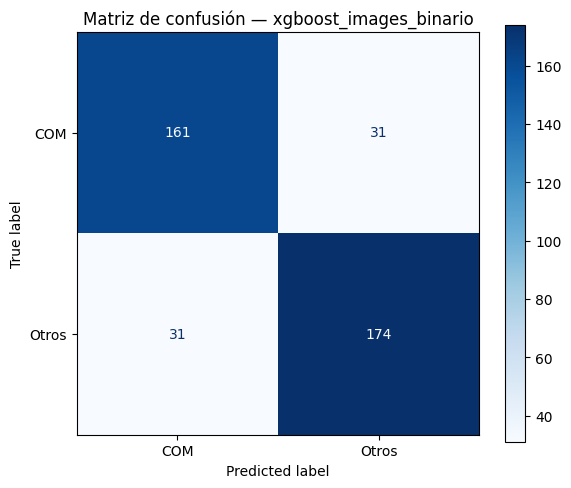

In [6]:
evaluation_result= xgboost_model.evaluate_cv(config, result["best_params"])
all_results.append(evaluation_result)